Лабораторна 2. Виконала студентка ФІТ 3-9 Бессараб Марія

**Завдання 1**

In [1]:
import kagglehub

path = kagglehub.dataset_download("nelgiriyewithana/global-youtube-statistics-2023")

print("Path to dataset files:", path)

100%|██████████| 60.1k/60.1k [00:00<00:00, 29.6MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/nelgiriyewithana/global-youtube-statistics-2023/versions/1


In [11]:
import pandas as pd
import os

csv_file = os.path.join(path, 'Global YouTube Statistics.csv')

df = pd.read_csv(csv_file, encoding='latin1')

df.head()

,rank,Youtuber,subscribers,video views,category,Title,uploads,Country,Abbreviation,channel_type,...,subscribers_for_last_30_days,created_year,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
0,1,T-Series,245000000,2.280000e+11,Music,T-Series,20082,India,IN,Music,...,2000000.0,2006.0,Mar,13.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
1,2,YouTube Movies,170000000,0.000000e+00,Film & Animation,youtubemovies,1,United States,US,Games,...,NaN,2006.0,Mar,5.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
2,3,MrBeast,166000000,2.836884e+10,Entertainment,MrBeast,741,United States,US,Entertainment,...,8000000.0,2012.0,Feb,20.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
3,4,Cocomelon - Nursery Rhymes,162000000,1.640000e+11,Education,Cocomelon - Nursery Rhymes,966,United States,US,Education,...,1000000.0,2006.0,Sep,1.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
4,5,SET India,159000000,1.480000e+11,Shows,SET India,116536,India,IN,Entertainment,...,1000000.0,2006.0,Sep,20.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880


In [12]:
print("Розмір датасету (рядки, стовпці):", df.shape)

Розмір датасету (рядки, стовпці): (995, 28)


In [13]:
# Перевіряємо, скільки пропусків у кожному стовпці
print("Кількість пропусків у кожному стовпці:")
print(df.isna().sum())

Кількість пропусків у кожному стовпці:
rank                                         0
Youtuber                                     0
subscribers                                  0
video views                                  0
category                                    46
Title                                        0
uploads                                      0
Country                                    122
Abbreviation                               122
channel_type                                30
video_views_rank                             1
country_rank                               116
channel_type_rank                           33
video_views_for_the_last_30_days            56
lowest_monthly_earnings                      0
highest_monthly_earnings                     0
lowest_yearly_earnings                       0
highest_yearly_earnings                      0
subscribers_for_last_30_days               337
created_year                                 5
created_month        

In [14]:
import pandas as pd
import numpy as np

numeric_cols = ['subscribers', 'video views', 'uploads']

#перетворюємо на числові типи, пропуски та некоректні значення стають NaN
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Кількість пропусків після перетворення у числовий тип:")
print(df[numeric_cols].isna().sum())

Кількість пропусків після перетворення у числовий тип:
subscribers    0
video views    0
uploads        0
dtype: int64


In [15]:
numeric_cols = ['subscribers', 'video views', 'uploads']

for col in numeric_cols:
    df[col].fillna(df[col].mean(), inplace=True)
    df[col] = df[col].astype(float)

print("Пропуски після заповнення середнім значенням:")
print(df[numeric_cols].isna().sum())

Пропуски після заповнення середнім значенням:
subscribers    0
video views    0
uploads        0
dtype: int64


/tmp/ipython-input-2008304744.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
/tmp/ipython-input-2008304744.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

In [17]:
# Кількість унікальних краʼн

unique_countries = df['Country'].nunique()
print("Кількість унікальних країн:", unique_countries)

Кількість унікальних країн: 49


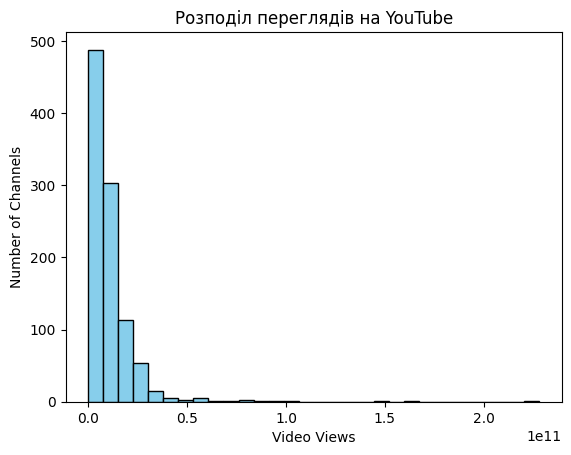

In [19]:
# Діаграма розподілу переглядів

import matplotlib.pyplot as plt
df['video views'].plot(kind='hist', bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Video Views')
plt.ylabel('Number of Channels')
plt.title('Розподіл переглядів на YouTube')
plt.show()

In [20]:
# Максимальна, мінімальна та середня кількість переглядів

print("Максимальні перегляди:", df['video views'].max())
print("Мінімальні перегляди:", df['video views'].min())
print("Середні перегляди:", df['video views'].mean())

Максимальні перегляди: 228000000000.0
Мінімальні перегляди: 0.0
Середні перегляди: 11039537052.03819


In [21]:
# Країна з найбільшою кількістю відео

most_videos_country = df['Country'].value_counts().idxmax()
print("Країна з найбільшою кількістю відео:", most_videos_country)

Країна з найбільшою кількістю відео: United States


In [22]:
# Відео з найбільшою та найменшою кількістю завантажень

max_uploads = df['uploads'].max()
print("Відео з найбільшою кількістю завантажень:")
print(df[df['uploads'] == max_uploads]['Title'])

min_uploads = df['uploads'].min()
print("Відео з найменшою кількістю завантажень:")
print(df[df['uploads'] == min_uploads]['Title'])

Відео з найбільшою кількістю завантажень:
95    ABP NEWS
Name: Title, dtype: object
Відео з найменшою кількістю завантажень:
5                         Music
12                       Gaming
57                   brightside
73     Luis Arturo Villar Sudek
102                        News
113       T- Series Apna Punjab
149                   luisfonsi
166                frostdiamond
180                Aditya Music
190           Sandeepmaheshwari
217       1MILLION Dance Studio
226               Fede Vigevani
236                  ChrisBrown
273                     FaZeRug
299                 Alan Becker
340                        YOLO
360           Minecraft - Topic
377                  linkinpark
386               FamilyGamesTV
394         Homem Aranha player
440              Masha e o Urso
463            Alejandro Basalo
468         Goodmythicalmorning
476                 Ajay Sharma
508            TheGameTheorists
544        Doggy Doggy Cartoons
554               werever2morro
592        

**Завдання 2.**

In [25]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sootersaalu/amazon-top-50-bestselling-books-2009-2019")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'amazon-top-50-bestselling-books-2009-2019' dataset.
Path to dataset files: /kaggle/input/amazon-top-50-bestselling-books-2009-2019


In [28]:
import pandas as pd
import os

csv_file_books = os.path.join('/kaggle/input/amazon-top-50-bestselling-books-2009-2019', 'bestsellers with categories.csv')

# Читаємо CSV і виводимо перші 10 рядків
df_books = pd.read_csv(csv_file_books)
df_books.head(10)

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction
5,A Dance with Dragons (A Song of Ice and Fire),George R. R. Martin,4.4,12643,11,2011,Fiction
6,A Game of Thrones / A Clash of Kings / A Storm...,George R. R. Martin,4.7,19735,30,2014,Fiction
7,A Gentleman in Moscow: A Novel,Amor Towles,4.7,19699,15,2017,Fiction
8,"A Higher Loyalty: Truth, Lies, and Leadership",James Comey,4.7,5983,3,2018,Non Fiction
9,A Man Called Ove: A Novel,Fredrik Backman,4.6,23848,8,2016,Fiction


In [29]:
# Розмір датасету
print("Розмір датасету (рядки, стовпці):", df_books.shape)


Розмір датасету (рядки, стовпці): (550, 7)


In [31]:
# Змінити назви колонок, назва з маленької букви, без пробілів через підкреслення.
df_books.columns = ['name', 'author', 'user_rating', 'reviews', 'price', 'year', 'genre']
df_books.head(3)

,name,author,user_rating,reviews,price,year,genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction


In [32]:
# Кількість пропусків у кожному стовпчику
print("Кількість пропусків у кожному стовпчику:")
print(df_books.isna().sum())

Кількість пропусків у кожному стовпчику:
name           0
author         0
user_rating    0
reviews        0
price          0
year           0
genre          0
dtype: int64


в змінних пропусків немає

In [33]:
# Унікальні жанри
unique_genres = df_books['genre'].unique()
print("Унікальні жанри:", unique_genres)

Унікальні жанри: ['Non Fiction' 'Fiction']


In [34]:
#изначте максимальну, мінімальну, медіанну ціну за допомогою методів max, min, mean, median

max_price = df_books['price'].max()
min_price = df_books['price'].min()
mean_price = df_books['price'].mean()
median_price = df_books['price'].median()

print("Максимальна ціна:", max_price)
print("Мінімальна ціна:", min_price)
print("Середня ціна:", mean_price)
print("Медіанна ціна:", median_price)

Максимальна ціна: 105
Мінімальна ціна: 0
Середня ціна: 13.1
Медіанна ціна: 11.0


In [35]:
#Найвищий рейтинг у датасеті та кількість книг з таким рейтингом

max_rating = df_books['user_rating'].max()
print("Найвищий рейтинг у датасеті:", max_rating)

num_max_rating_books = df_books[df_books['user_rating'] == max_rating].shape[0]
print("Кількість книг з найвищим рейтингом:", num_max_rating_books)

Найвищий рейтинг у датасеті: 4.9
Кількість книг з найвищим рейтингом: 52


In [36]:
#Книга з найбільшою кількістю відгуків
max_reviews = df_books['reviews'].max()

book_max_reviews = df_books[df_books['reviews'] == max_reviews]['name']
print("Книга з найбільшою кількістю відгуків:", book_max_reviews.values)

Книга з найбільшою кількістю відгуків: ['Where the Crawdads Sing']


In [38]:
# Найдорожча книга серед Top-50 2010 року
max_price_2010 = df_books[df_books['year'] == 2010]['price'].max()

book_max_price_2010 = df_books[(df_books['year'] == 2010) & (df_books['price'] == max_price_2010)]['name']
print("Найдорожча книга 2010 року:", book_max_price_2010.values)

Найдорожча книга 2010 року: ['Publication Manual of the American Psychological Association, 6th Edition']


In [40]:
#Кількість книг жанру Fiction у Top-50 2012 року
num_fiction_2012 = df_books[(df_books['genre'] == 'Fiction') & (df_books['year'] == 2012)].shape[0]
print("Кількість книг жанру Fiction у 2012 році:", num_fiction_2012)

Кількість книг жанру Fiction у 2012 році: 21


In [41]:
#Кількість книг з рейтингом 4.9 у 2010 або 2011 роках

num_high_rating_books = df_books[(df_books['user_rating'] == 4.9) & (df_books['year'].isin([2010, 2011]))].shape[0]
print("Кількість книг з рейтингом 4.9 у 2010 та 2011 роках:", num_high_rating_books)

Кількість книг з рейтингом 4.9 у 2010 та 2011 роках: 1


In [42]:
#Вивести максимальну і мінімальну ціну для жанру Fiction I NonFiction (за допомогою методів groupby та agg, для підрахунку мінімальних та максимальних значень використовуйте max та min). Використовуйте тількі потрібні вам стовпці.

price_stats = df_books.groupby('genre')[['price']].agg([min, max])

print(price_stats)

            price     
              min  max
genre                 
Fiction         0   82
Non Fiction     0  105


/tmp/ipython-input-3307847109.py:3: FutureWarning: The provided callable <built-in function min> is currently using SeriesGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  price_stats = df_books.groupby('genre')[['price']].agg([min, max])
/tmp/ipython-input-3307847109.py:3: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  price_stats = df_books.groupby('genre')[['price']].agg([min, max])
